Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside Jupyter Notebook
%matplotlib inline

Load the Dataset

In [3]:
df = pd.read_csv("Uber Request Data.csv")

Display the First 5 Rows

In [5]:
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11-07-2016 11:51,11-07-2016 13:00
1,867,Airport,1.0,Trip Completed,11-07-2016 17:57,11-07-2016 18:47
2,1807,City,1.0,Trip Completed,12-07-2016 09:17,12-07-2016 09:58
3,2532,Airport,1.0,Trip Completed,12-07-2016 21:08,12-07-2016 22:03
4,3112,City,1.0,Trip Completed,13-07-2016 08:33,13-07-2016 09:25


Check the Shape of the Dataset

In [7]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(6745, 6)


Display Column Names

In [9]:
print("Columns:")
print(df.columns)

Columns:
Index(['Request id', 'Pickup point', 'Driver id', 'Status',
       'Request timestamp', 'Drop timestamp'],
      dtype='str')


Dataset Information

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   str    
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   str    
 4   Request timestamp  6745 non-null   str    
 5   Drop timestamp     2831 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 596.4 KB


Statistical Summary

In [13]:
df.describe(include='all')

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
count,6745.000000,6745,4095.000000,6745,6745,2831
unique,NaN,2,NaN,3,4016,2282
top,NaN,City,NaN,Trip Completed,15-07-2016 19:19,13-07-2016 08:53
freq,NaN,3507,NaN,2831,8,5
mean,3384.644922,NaN,149.501343,NaN,NaN,NaN
std,1955.099667,NaN,86.051994,NaN,NaN,NaN
min,1.000000,NaN,1.000000,NaN,NaN,NaN
25%,1691.000000,NaN,75.000000,NaN,NaN,NaN
50%,3387.000000,NaN,149.000000,NaN,NaN,NaN
75%,5080.000000,NaN,224.000000,NaN,NaN,NaN


Check Missing Values

In [15]:
# Check missing values
print(df.isnull().sum())

Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
dtype: int64


Check Duplicate Rows

In [17]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [19]:
df = df.drop_duplicates()
print("Dataset Shape after removing duplicates:", df.shape)

Dataset Shape after removing duplicates: (6745, 6)


Convert Timestamp Columns

In [23]:
# Convert timestamp columns
df['Request timestamp'] = pd.to_datetime(
    df['Request timestamp'],
    format='%d-%m-%Y %H:%M'
)

df['Drop timestamp'] = pd.to_datetime(
    df['Drop timestamp'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

In [25]:
df.dtypes

Request id                    int64
Pickup point                    str
Driver id                   float64
Status                          str
Request timestamp    datetime64[us]
Drop timestamp       datetime64[us]
dtype: object

Create the Hour Column

In [27]:
# Create Hour column
df['Hour'] = df['Request timestamp'].dt.hour

# Display first 5 rows
df[['Request timestamp', 'Hour']].head()

,Request timestamp,Hour
0,2016-07-11 11:51:00,11
1,2016-07-11 17:57:00,17
2,2016-07-12 09:17:00,9
3,2016-07-12 21:08:00,21
4,2016-07-13 08:33:00,8


Create the Day Column

In [29]:
# Create Day column
df['Day'] = df['Request timestamp'].dt.day_name()

# Display first 5 rows
df[['Request timestamp', 'Day']].head()

,Request timestamp,Day
0,2016-07-11 11:51:00,Monday
1,2016-07-11 17:57:00,Monday
2,2016-07-12 09:17:00,Tuesday
3,2016-07-12 21:08:00,Tuesday
4,2016-07-13 08:33:00,Wednesday


Create the Time Slot Column

In [31]:
# Function to categorize time slots
def time_slot(hour):
    if 0 <= hour < 5:
        return 'Late Night'
    elif 5 <= hour < 10:
        return 'Morning'
    elif 10 <= hour < 17:
        return 'Day'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

# Apply the function
df['Time Slot'] = df['Hour'].apply(time_slot)

# Display first 5 rows
df[['Hour', 'Time Slot']].head()

,Hour,Time Slot
0,11,Day
1,17,Evening
2,9,Morning
3,21,Night
4,8,Morning


Verify the New Columns

In [33]:
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,Hour,Day,Time Slot
0,619,Airport,1.0,Trip Completed,2016-07-11 11:51:00,2016-07-11 13:00:00,11,Monday,Day
1,867,Airport,1.0,Trip Completed,2016-07-11 17:57:00,2016-07-11 18:47:00,17,Monday,Evening
2,1807,City,1.0,Trip Completed,2016-07-12 09:17:00,2016-07-12 09:58:00,9,Tuesday,Morning
3,2532,Airport,1.0,Trip Completed,2016-07-12 21:08:00,2016-07-12 22:03:00,21,Tuesday,Night
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:00,2016-07-13 09:25:00,8,Wednesday,Morning


Check the Time Slot Distribution

In [35]:
df['Time Slot'].value_counts()

Time Slot
Morning       2103
Evening       1893
Day           1224
Night          947
Late Night     578
Name: count, dtype: int64

Trip Status Distribution

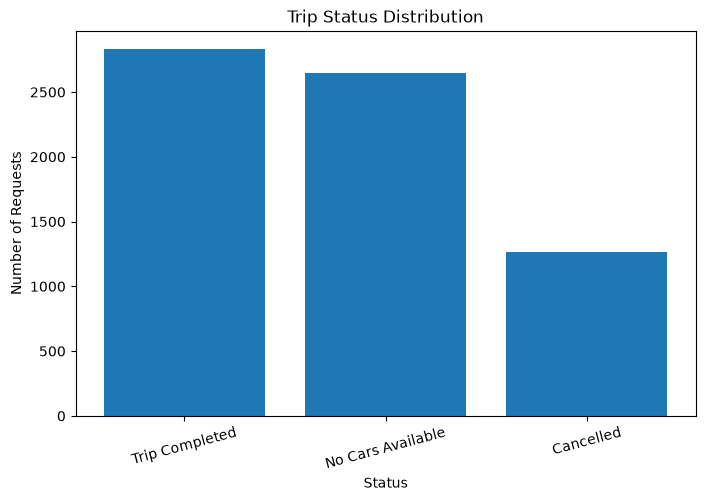

In [37]:
import matplotlib.pyplot as plt

status_count = df['Status'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(status_count.index, status_count.values)
plt.title("Trip Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Requests")
plt.xticks(rotation=15)
plt.show()

Pickup Point Distribution

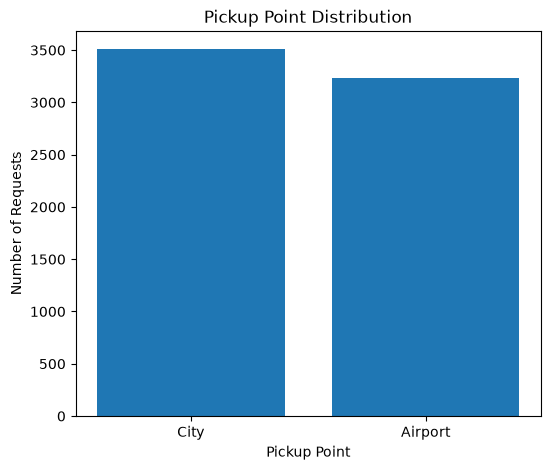

In [39]:
pickup_count = df['Pickup point'].value_counts()

plt.figure(figsize=(6,5))
plt.bar(pickup_count.index, pickup_count.values)
plt.title("Pickup Point Distribution")
plt.xlabel("Pickup Point")
plt.ylabel("Number of Requests")
plt.show()

Time Slot Distribution

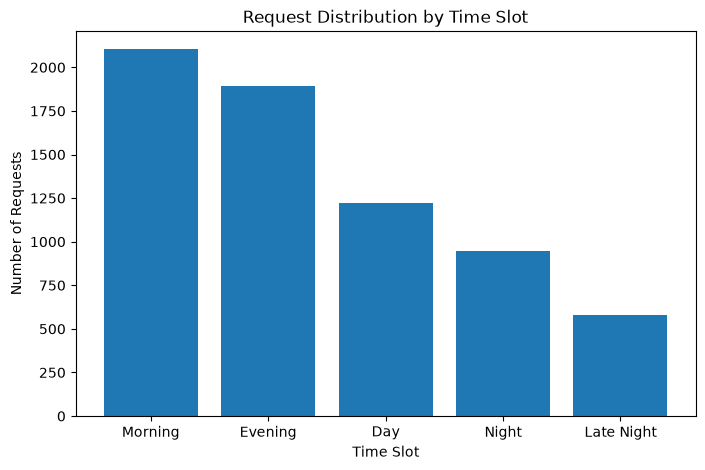

In [41]:
time_slot_count = df['Time Slot'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(time_slot_count.index, time_slot_count.values)
plt.title("Request Distribution by Time Slot")
plt.xlabel("Time Slot")
plt.ylabel("Number of Requests")
plt.show()

Hour-wise Requests

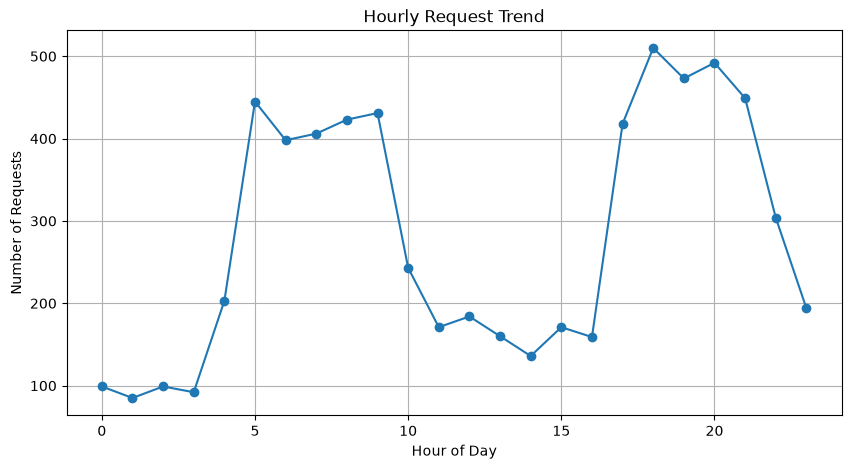

In [43]:
hour_count = df['Hour'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(hour_count.index, hour_count.values, marker='o')
plt.title("Hourly Request Trend")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Requests")
plt.grid(True)
plt.show()

Day-wise Requests

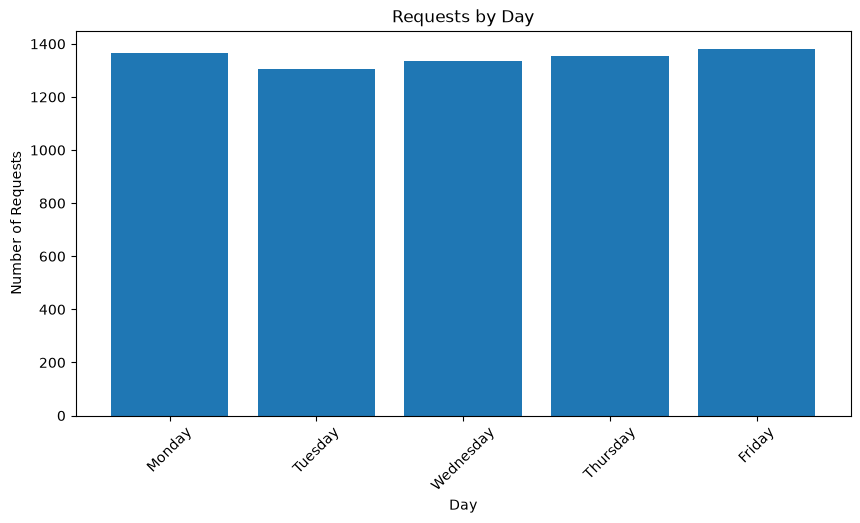

In [45]:
day_order = [
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'
]

day_count = df['Day'].value_counts().reindex(day_order)

plt.figure(figsize=(10,5))
plt.bar(day_count.index, day_count.values)
plt.title("Requests by Day")
plt.xlabel("Day")
plt.ylabel("Number of Requests")
plt.xticks(rotation=45)
plt.show()

Status vs Pickup Point

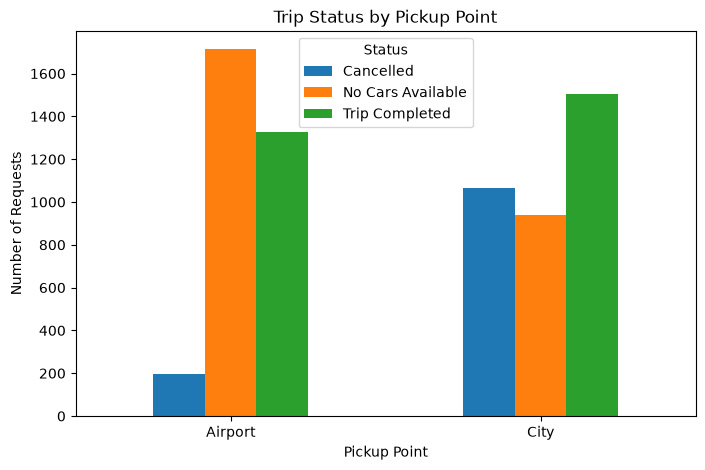

In [47]:
status_pickup = pd.crosstab(df['Pickup point'], df['Status'])

status_pickup.plot(kind='bar', figsize=(8,5))

plt.title("Trip Status by Pickup Point")
plt.xlabel("Pickup Point")
plt.ylabel("Number of Requests")
plt.xticks(rotation=0)
plt.show()

Status vs Time Slot

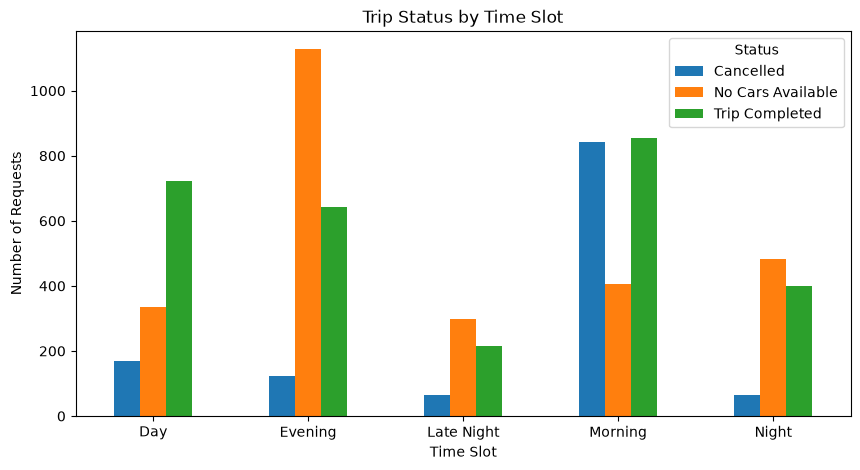

In [49]:
status_time = pd.crosstab(df['Time Slot'], df['Status'])

status_time.plot(kind='bar', figsize=(10,5))

plt.title("Trip Status by Time Slot")
plt.xlabel("Time Slot")
plt.ylabel("Number of Requests")
plt.xticks(rotation=0)
plt.show()

Save the Cleaned Dataset

In [51]:
df.to_csv("Uber_Request_Data_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# Business Insights

1. Most ride requests were successfully completed.
2. A large number of requests failed because no cars were available.
3. The City generated more ride requests than the Airport.
4. The Airport experienced the highest number of "No Cars Available" cases.
5. The City had more cancelled trips than the Airport.
6. Peak demand occurred during specific hours and time slots.
7. Better driver allocation during peak hours can reduce the supply-demand gap.

# Conclusion

The analysis identified key demand patterns and highlighted supply shortages at the Airport and high cancellation rates in the City. Improving driver availability during peak periods and optimizing resource allocation can significantly enhance customer satisfaction.